# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama        : Rifqi Rahardian
- Email       : rifqirahardian2@gmail.com
- Id Dicoding : rifqi_rahardian_GraY

## Persiapan 

#### Menyiapkan Library yang dibutuhkan


In [ ]:
# Standard Libraries 
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import joblib

# Plot Style 
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

### Menyiapkan data yang akan digunakan

In [73]:
# Load dataset
df = pd.read_csv('data.csv', sep=';')

## Data Understanding

In [74]:
# Inspeksi awal dataset
print(f'Shape        : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Tipe data    : {df.dtypes.value_counts().to_dict()}')
df.head()

Shape        : 4,424 baris × 37 kolom
Missing values: 0
Tipe data    : {dtype('int64'): 29, dtype('float64'): 7, dtype('O'): 1}


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [75]:
# Informasi kolom dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [76]:
# Statistik deskriptif
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.000000,1.178571,0.605747,1.000000,1.000000,1.000000,1.000000,6.000000
Application_mode,4424.000000,18.669078,17.484682,1.000000,1.000000,17.000000,39.000000,57.000000
Application_order,4424.000000,1.727848,1.313793,0.000000,1.000000,1.000000,2.000000,9.000000
Course,4424.000000,8856.642631,2063.566416,33.000000,9085.000000,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.000000,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous_qualification,4424.000000,4.577758,10.216592,1.000000,1.000000,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.000000,132.613314,13.188332,95.000000,125.000000,133.100000,140.000000,190.000000
Nacionality,4424.000000,1.873192,6.914514,1.000000,1.000000,1.000000,1.000000,109.000000
Mothers_qualification,4424.000000,19.561935,15.603186,1.000000,2.000000,19.000000,37.000000,44.000000
Fathers_qualification,4424.000000,22.275316,15.343108,1.000000,3.000000,19.000000,37.000000,44.000000


### Exploratory Data Analysis (EDA)

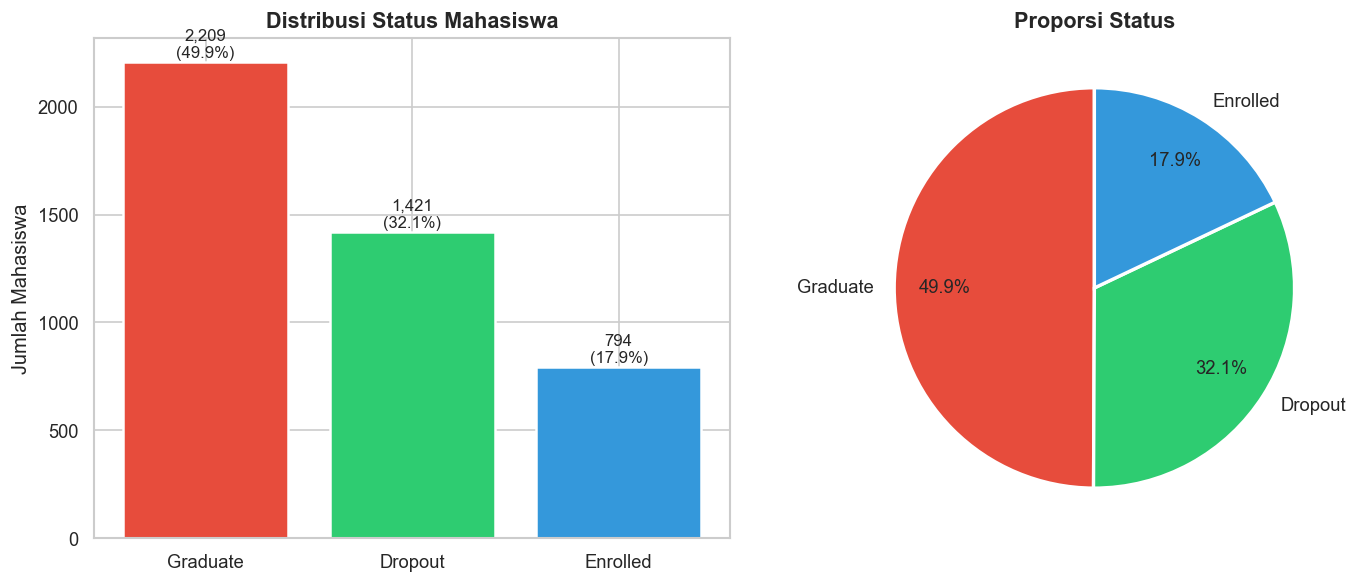

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [77]:
# Distribusi Target Variable
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['Status'].value_counts()
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Mahasiswa')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(linewidth=2, edgecolor='white'))
axes[1].set_title('Proporsi Status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(counts)

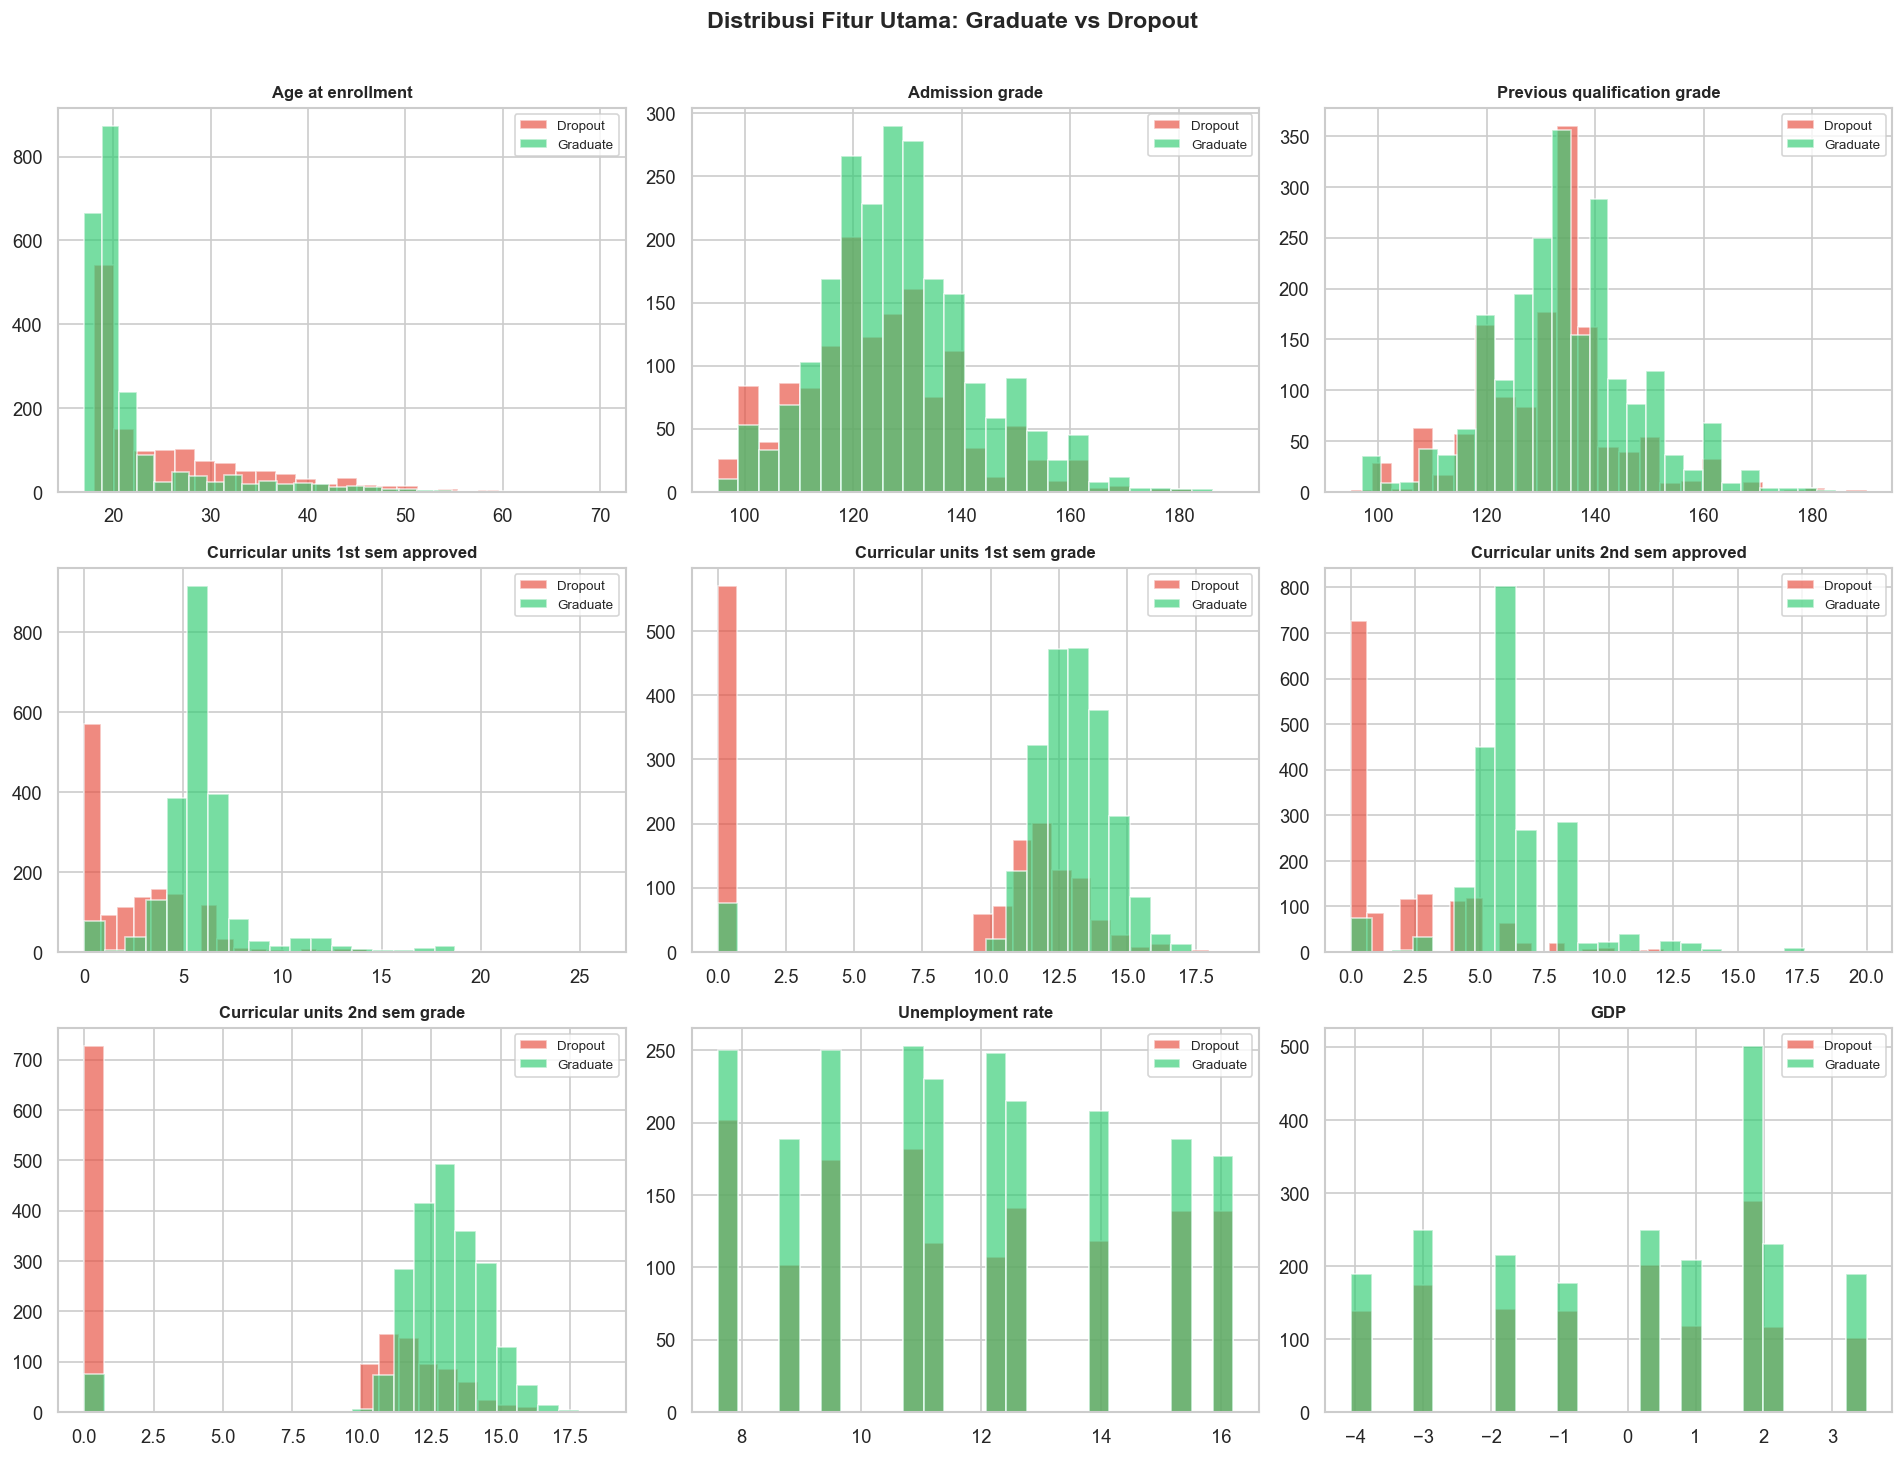

In [78]:
# Eksplorasi Fitur Numerik
key_features = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Unemployment_rate', 'GDP'
]

df_vis = df[df['Status'].isin(['Graduate', 'Dropout'])].copy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for status, color in zip(['Dropout', 'Graduate'], ['#e74c3c', '#2ecc71']):
        subset = df_vis[df_vis['Status'] == status][feat]
        axes[i].hist(subset, bins=25, alpha=0.65, color=color, label=status, edgecolor='white')
    axes[i].set_title(feat.replace('_', ' '), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Utama: Graduate vs Dropout', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

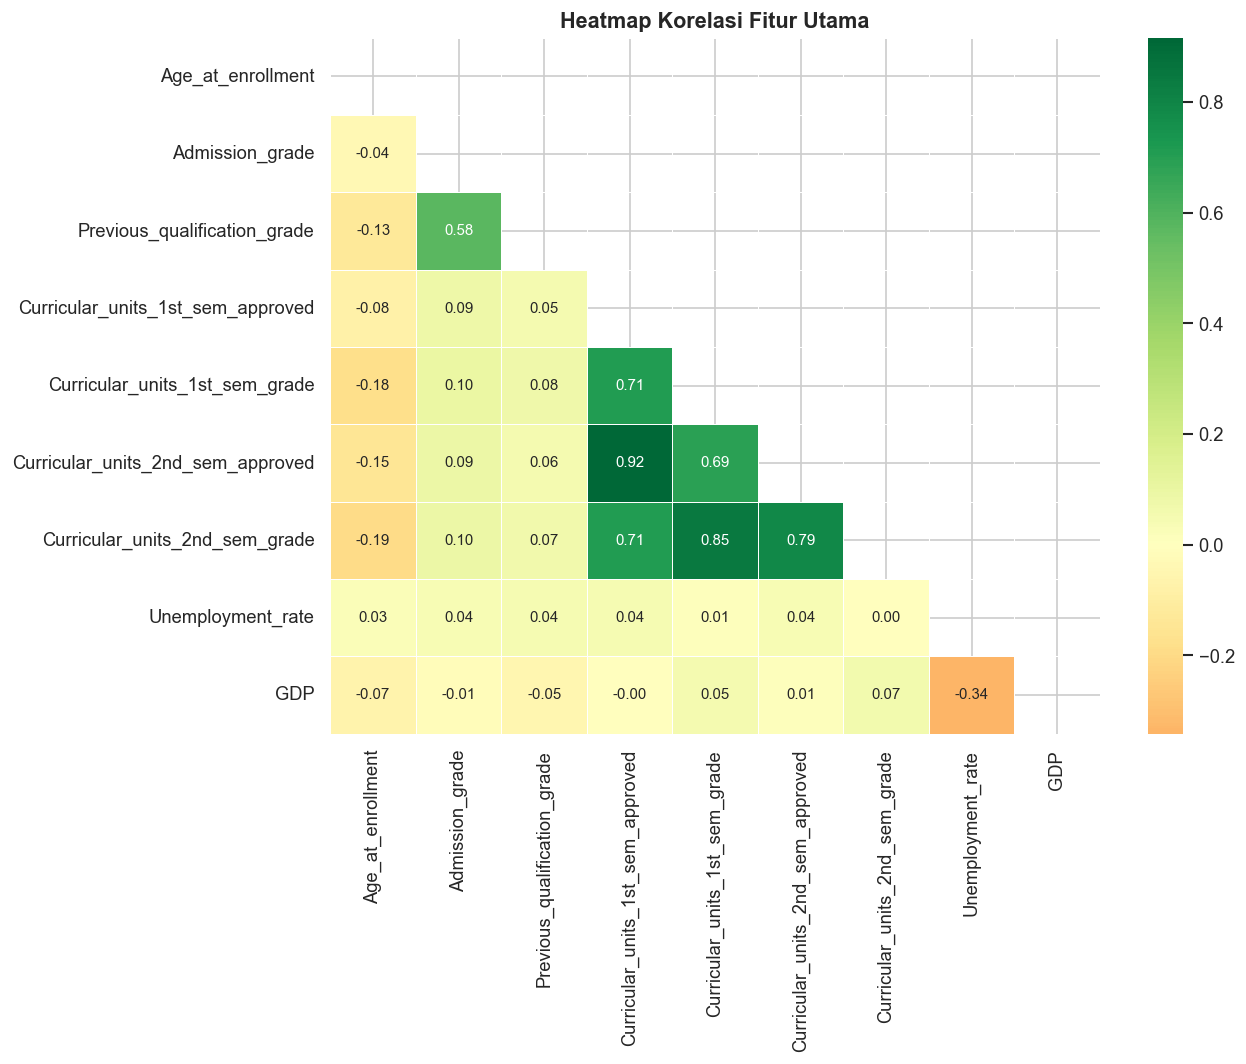

In [79]:
# Korelasi Antar Fitur
corr_matrix = df_vis[key_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Heatmap Korelasi Fitur Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

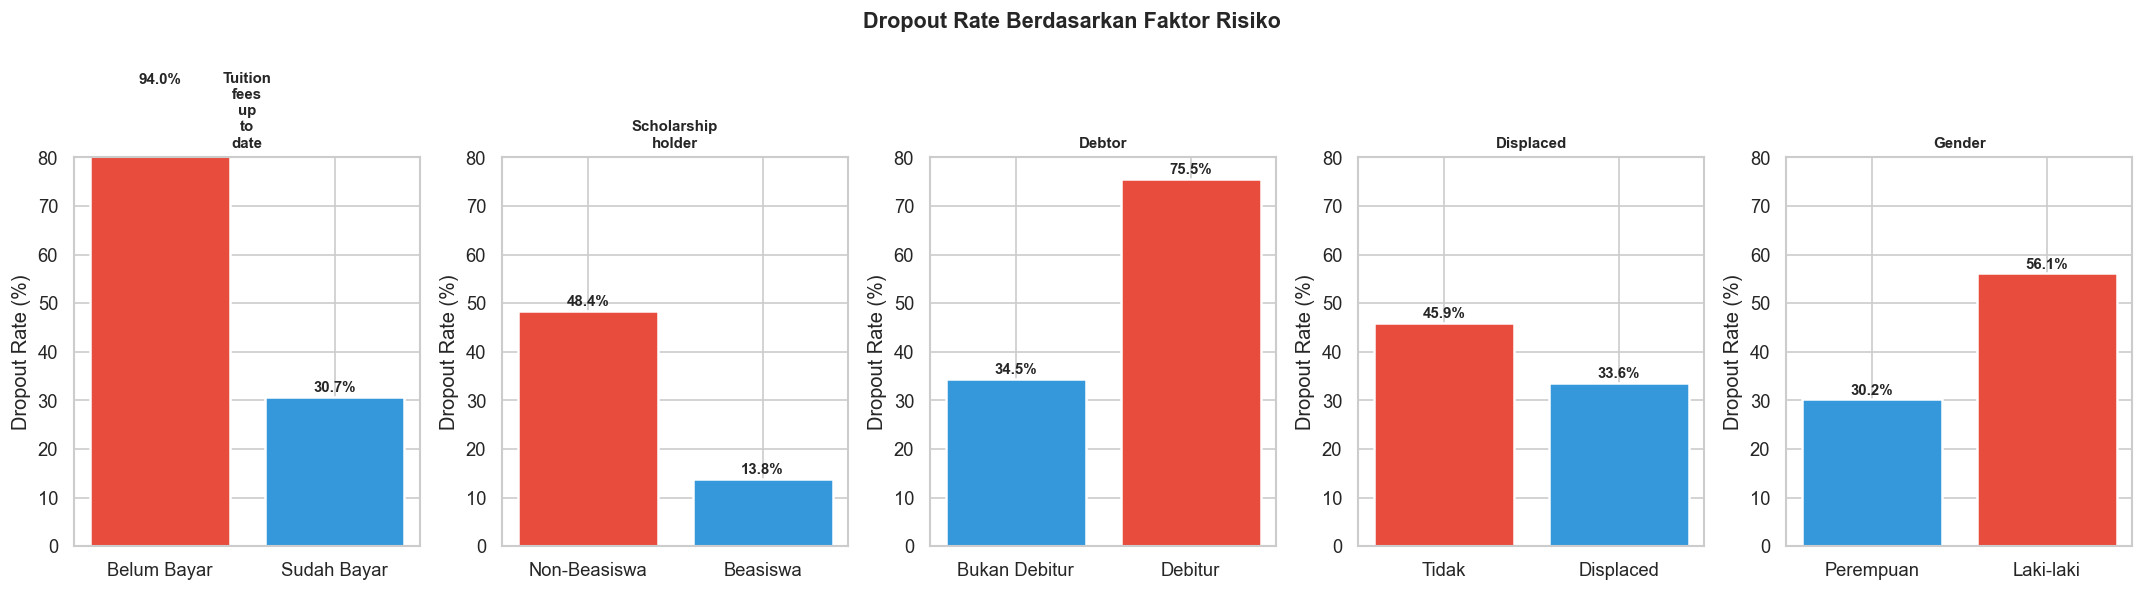

In [80]:
# Analisis Faktor Risiko Dropout
binary_features = ['Tuition_fees_up_to_date', 'Scholarship_holder',
                   'Debtor', 'Displaced', 'Gender']

fig, axes = plt.subplots(1, len(binary_features), figsize=(18, 5))
label_maps = {
    'Tuition_fees_up_to_date': {0: 'Belum Bayar', 1: 'Sudah Bayar'},
    'Scholarship_holder': {0: 'Non-Beasiswa', 1: 'Beasiswa'},
    'Debtor': {0: 'Bukan Debitur', 1: 'Debitur'},
    'Displaced': {0: 'Tidak', 1: 'Displaced'},
    'Gender': {0: 'Perempuan', 1: 'Laki-laki'}
}

for ax, feat in zip(axes, binary_features):
    dropout_rate = df_vis.groupby(feat).apply(
        lambda x: (x['Status'] == 'Dropout').mean() * 100
    )
    lm = label_maps.get(feat, {})
    dropout_rate.index = [lm.get(i, str(i)) for i in dropout_rate.index]
    
    bars = ax.bar(dropout_rate.index, dropout_rate.values,
                  color=['#e74c3c' if v > 35 else '#3498db' for v in dropout_rate.values],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(feat.replace('_', '\n'), fontsize=9, fontweight='bold')
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_ylim(0, 80)
    for bar, val in zip(bars, dropout_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Dropout Rate Berdasarkan Faktor Risiko', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Preparation

In [81]:
# Filter: hanya Graduate & Dropout 
df_model = df[df['Status'].isin(['Graduate', 'Dropout'])].copy()
print(f'Dataset setelah filter Enrolled: {df_model.shape}')
print(df_model['Status'].value_counts())

Dataset setelah filter Enrolled: (3630, 37)
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [82]:
# Encoding Target Variable
# Dropout = 0, Graduate = 1
le = LabelEncoder()
df_model['Status_encoded'] = le.fit_transform(df_model['Status'])
print('Mapping kelas:', dict(zip(le.classes_, le.transform(le.classes_))))

Mapping kelas: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}


In [83]:
# Pemisahan Fitur dan Target 
X = df_model.drop(['Status', 'Status_encoded'], axis=1)
y = df_model['Status_encoded']

feature_names = X.columns.tolist()
print(f'Jumlah fitur : {len(feature_names)}')
print(f'Distribusi y : {dict(zip(le.classes_, np.bincount(y)))}')

Jumlah fitur : 36
Distribusi y : {'Dropout': np.int64(1421), 'Graduate': np.int64(2209)}


In [84]:
# Feature Engineering
# Rasio approval rate per semester
X = X.copy()
X['approval_rate_sem1'] = np.where(
    X['Curricular_units_1st_sem_enrolled'] > 0,
    X['Curricular_units_1st_sem_approved'] / X['Curricular_units_1st_sem_enrolled'],
    0
)
X['approval_rate_sem2'] = np.where(
    X['Curricular_units_2nd_sem_enrolled'] > 0,
    X['Curricular_units_2nd_sem_approved'] / X['Curricular_units_2nd_sem_enrolled'],
    0
)
# Rata-rata grade gabungan
X['avg_grade'] = (X['Curricular_units_1st_sem_grade'] + X['Curricular_units_2nd_sem_grade']) / 2

print('Total fitur:', X.shape[1])

Total fitur: 39


In [85]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set : {X_train.shape[0]:,} sampel')
print(f'Test set  : {X_test.shape[0]:,} sampel')
print(f'Distribusi train: {dict(zip(le.classes_, np.bincount(y_train)))}')
print(f'Distribusi test : {dict(zip(le.classes_, np.bincount(y_test)))}')

Train set : 2,904 sampel
Test set  : 726 sampel
Distribusi train: {'Dropout': np.int64(1137), 'Graduate': np.int64(1767)}
Distribusi test : {'Dropout': np.int64(284), 'Graduate': np.int64(442)}


In [86]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


## Modeling

### Pemilihan Model

Membandingkan 3 model:
1. Random Forest
2. Gradient Boosting
3. Logistic Regression

**Pilihan utama: Random Forest** — karena dataset campuran dan memberikan feature importance yang mudah diinterpretasi.

In [87]:
# Definisi Model 
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    )
}

In [88]:
# Cross-Validation Comparison 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Random Forest             | ROC-AUC: 0.9536 ± 0.0078
Gradient Boosting         | ROC-AUC: 0.9509 ± 0.0063
Logistic Regression       | ROC-AUC: 0.9535 ± 0.0009


In [89]:
# Training Model Terbaik (Random Forest) 
best_model = models['Random Forest']
best_model.fit(X_train_scaled, y_train)

print(f'   Training Accuracy: {best_model.score(X_train_scaled, y_train):.4f}')

   Training Accuracy: 0.9442


## Evaluation

In [90]:
# Prediksi 
y_pred      = best_model.predict(X_test_scaled)
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)

print(f'Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f' ROC-AUC Score  : {auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy  : 0.9105 (91.05%)
 ROC-AUC Score  : 0.9566

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.92      0.84      0.88       284
    Graduate       0.90      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



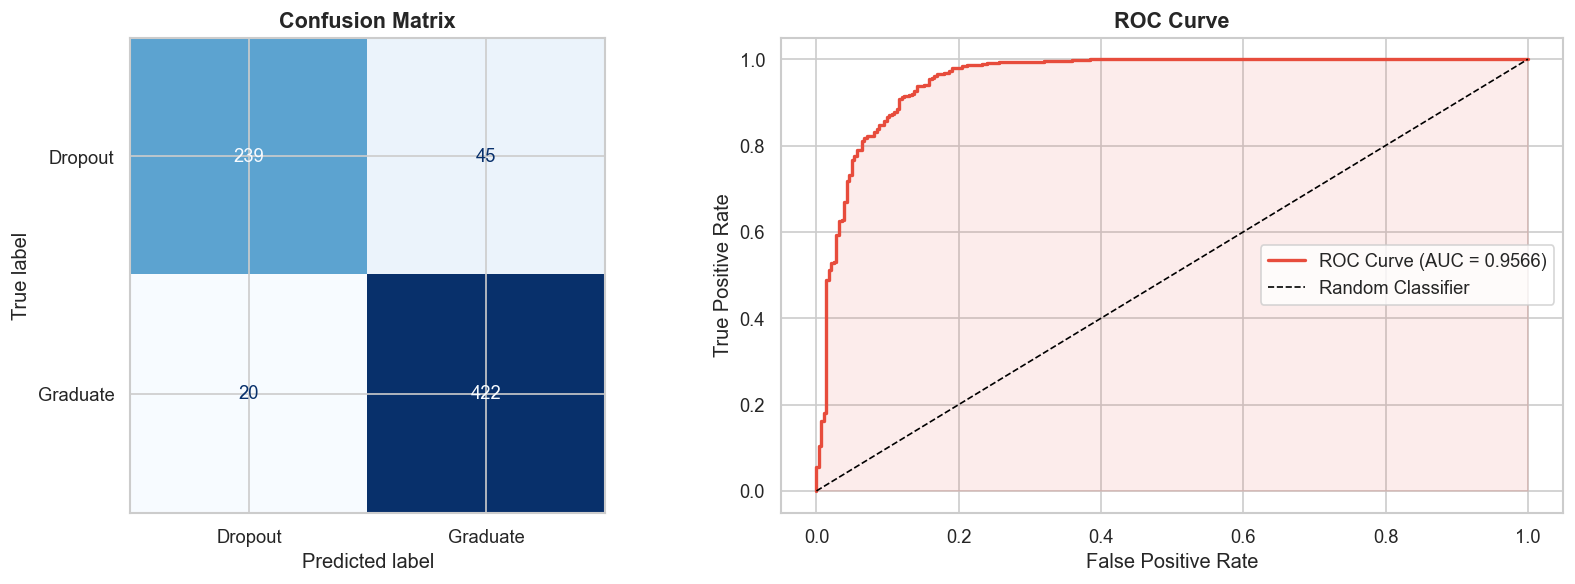

In [91]:
#  Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

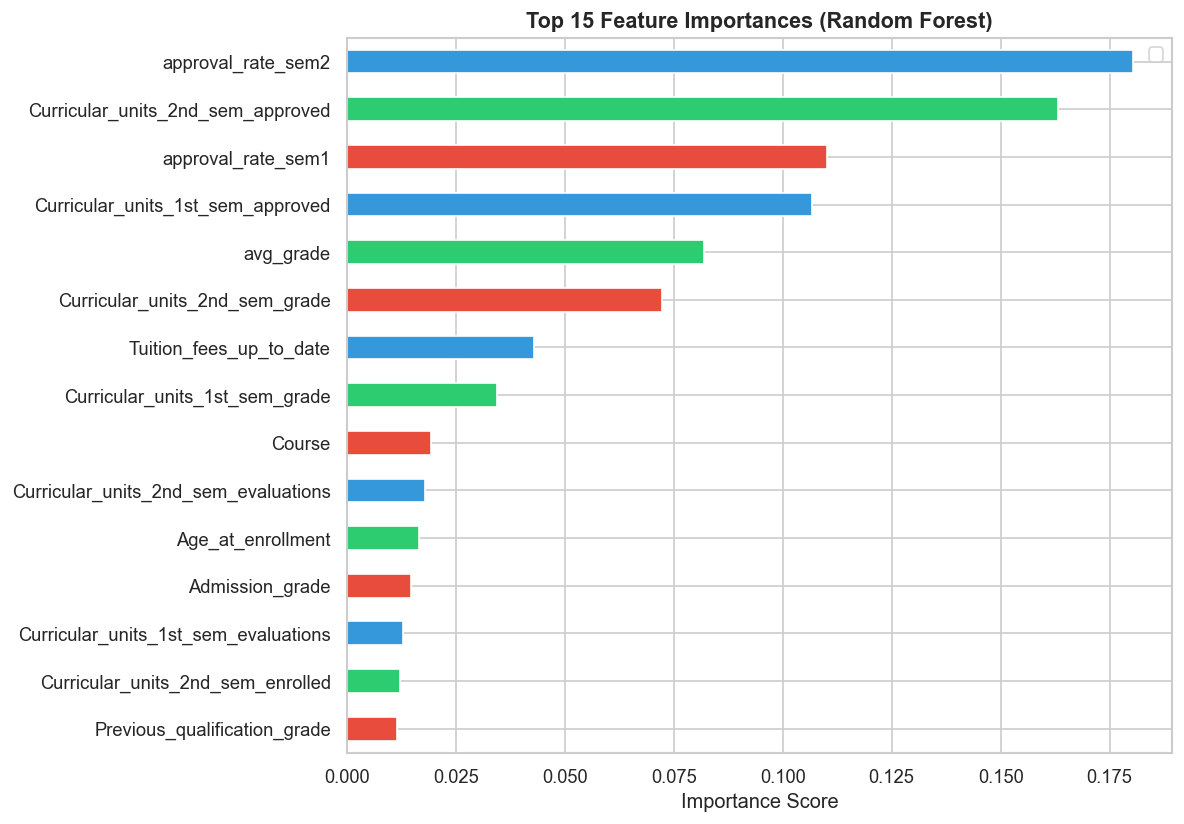


 Top 5 Fitur Terpenting:
  1. approval_rate_sem2: 0.1804 (18.04%)
  2. Curricular_units_2nd_sem_approved: 0.1632 (16.32%)
  3. approval_rate_sem1: 0.1101 (11.01%)
  4. Curricular_units_1st_sem_approved: 0.1067 (10.67%)
  5. avg_grade: 0.0820 (8.20%)


In [92]:
# Feature Importance 
feat_imp = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()

plt.tight_layout()
plt.show()

print('\n Top 5 Fitur Terpenting:')
for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {feat}: {imp:.4f} ({imp*100:.2f}%)')

In [93]:
# Perbandingan Semua Model
comparison = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_p = model.predict(X_test_scaled)
    y_pp = model.predict_proba(X_test_scaled)[:, 1]
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_p),
        'ROC-AUC': roc_auc_score(y_test, y_pp),
        'CV ROC-AUC Mean': cv_results[name].mean(),
        'CV ROC-AUC Std': cv_results[name].std()
    })

df_compare = pd.DataFrame(comparison).set_index('Model')
print('\nPerbandingan Performa Model:')
df_compare.style.highlight_max(color='lightgreen', subset=['Accuracy','ROC-AUC'])


Perbandingan Performa Model:


,Accuracy,ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std
Model,,,,
Random Forest,0.910468,0.956575,0.953598,0.007794
Gradient Boosting,0.914601,0.947804,0.950887,0.006283
Logistic Regression,0.902204,0.950083,0.953531,0.000897


In [94]:
#  Simpan artefak model 
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(le,         'label_encoder.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']